<a href="https://vigneashpandiyan.github.io/publications/Codes/" target="_blank" rel="noopener noreferrer">
  <img src="https://vigneashpandiyan.github.io/images/Link.png"
       style="max-width: 800px; width: 100%; height: auto;">
</a>

# Vision Transformer
A Vision Transformer (ViT) is an image model that uses a Transformer encoder (self-attention) instead of convolutions to process images. The key trick is to turn an image into a sequence of tokens, just like words in NLP.

![67e0e1c8c7139275092d8d50_66ad0d924f21aef77ca02ab9_66801abf0af4eff72056274b_Attention_Mechanism_(16)[1].png](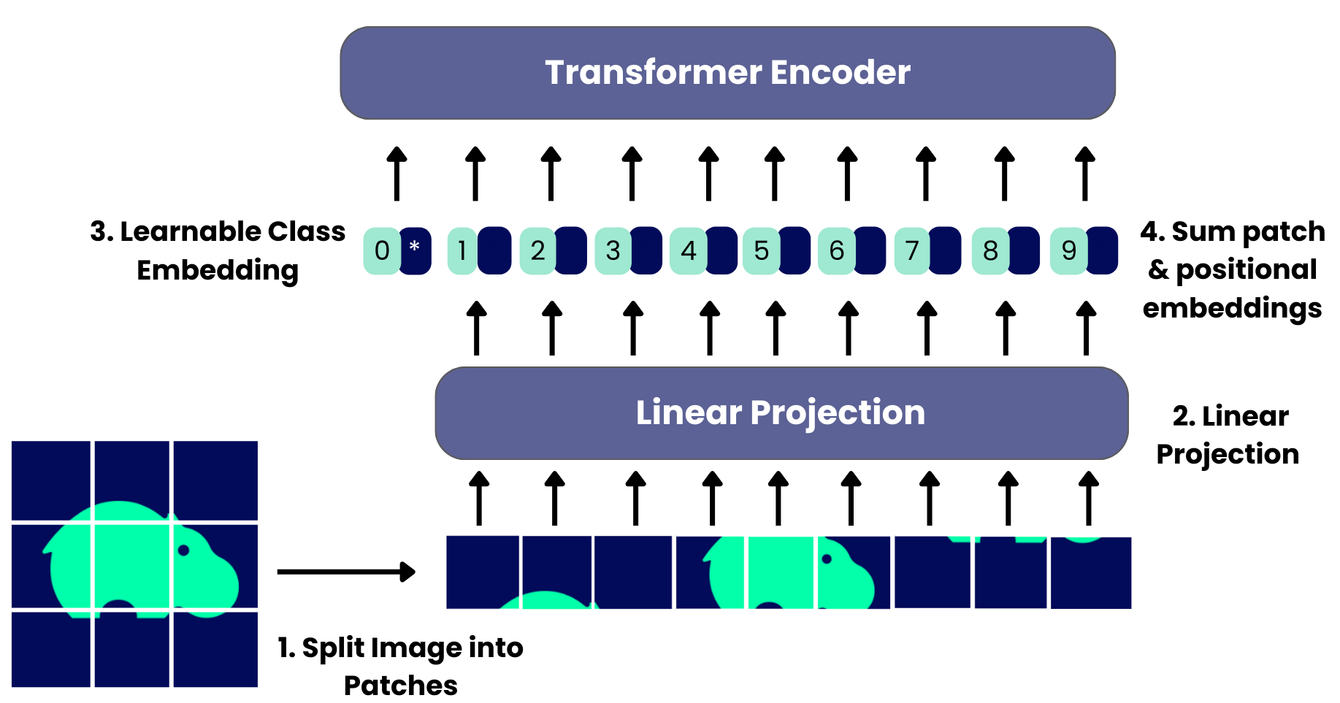)

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 2. Define a transformation pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 3. Download and load the MNIST training dataset
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
print("MNIST training dataset loaded successfully.")

# 4. Download and load the MNIST test dataset
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
print("MNIST test dataset loaded successfully.")

# 5. Create a DataLoader for the training dataset
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
print(f"Train DataLoader created with batch size 64 and {len(train_loader)} batches.")

# 6. Create a DataLoader for the test dataset
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)
print(f"Test DataLoader created with batch size 1000 and {len(test_loader)} batches.")

# 7. Determine the device to use for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

The section proceeds largely tye same as in the previous modules.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Helper function to ensure tensor is pair-wise divisible
def _pair(x):
    return x if isinstance(x, tuple) else (x, x)

# 1. Patch Embedding Layer
class PatchEmbed(nn.Module):
    def __init__(self, img_size, patch_size, in_chans=1, embed_dim=768):
        super().__init__()
        img_size = _pair(img_size)
        patch_size = _pair(patch_size)
        num_patches = (img_size[0] // patch_size[0]) * (img_size[1] // patch_size[1])
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = num_patches
        self.embed_dim = embed_dim

        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        B, C, H, W = x.shape
        assert H == self.img_size[0] and W == self.img_size[1], \
            f"Input image size ({H}*{W}) doesn't match model ({self.img_size[0]}*{self.img_size[1]})."
        x = self.proj(x).flatten(2).transpose(1, 2)  # B, C, H, W -> B, embed_dim, num_patches -> B, num_patches, embed_dim
        return x

# 2. Multi-head Self-Attention (MSA)
class Attention(nn.Module):
    def __init__(self, embed_dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = embed_dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]   # make q, k, v distinct

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

# 3. MLP Block (Feed-Forward Network)
class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

# 4. Transformer Encoder Block
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4., qkv_bias=False, drop=0., attn_drop=0.,
                 act_layer=nn.GELU, norm_layer=nn.LayerNorm):
        super().__init__()
        self.norm1 = norm_layer(embed_dim)
        self.attn = Attention(embed_dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = norm_layer(embed_dim)
        mlp_hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = Mlp(in_features=embed_dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x




## Vision Transformer Class

In [ ]:
# 5. Vision Transformer (ViT) Model
class VisionTransformer(nn.Module):
    def __init__(self, img_size=28, patch_size=7, in_chans=1, num_classes=10,
                 embed_dim=64, num_transformer_blocks=2, num_heads=8, mlp_ratio=4.,
                 qkv_bias=False, drop_rate=0., attn_drop_rate=0.):
        super().__init__()
        self.num_classes = num_classes
        self.embed_dim = embed_dim
        self.num_transformer_blocks = num_transformer_blocks

        self.patch_embed = PatchEmbed(img_size=img_size, patch_size=patch_size, in_chans=in_chans, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)

        self.blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, qkv_bias=qkv_bias,
                drop=drop_rate, attn_drop=attn_drop_rate)
            for _ in range(num_transformer_blocks)])
        self.norm = nn.LayerNorm(embed_dim)

        self.head = nn.Linear(embed_dim, num_classes) if num_classes > 0 else nn.Identity()

        # Initialize position embeddings (simplified for fixed size here, typically requires more complex interpolation)
        # For this simple example, we'll just initialize them. In a real scenario, you'd want to use more robust init or load pre-trained.
        nn.init.trunc_normal_(self.pos_embed, std=.02)
        nn.init.trunc_normal_(self.cls_token, std=.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward_features(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)

        cls_token = self.cls_token.expand(B, -1, -1)  # Expand (1, 1, embed_dim) to (B, 1, embed_dim)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        return x[:, 0] # Return the CLS token for classification

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x

print("Vision Transformer classes defined successfully.")

## Instantiate Vision Transformer Model

In [ ]:
vit_model = VisionTransformer(
    img_size=28,
    patch_size=7,
    in_chans=1,
    num_classes=10,
    embed_dim=64,
    num_transformer_blocks=2,
    num_heads=8 # Assuming head_dim = embed_dim / num_heads = 64/8 = 8
)
vit_model.to(device)
print(f"Vision Transformer model instantiated with img_size=28, patch_size=7, embed_dim=64, num_transformer_blocks=2, num_heads=8 and moved to {device}.")

## Defining Loss Function and Optimizer


In [ ]:
import torch.optim as optim

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer with SGD, model parameters, learning rate, and momentum
optimizer = optim.SGD(vit_model.parameters(), lr=0.01, momentum=0.9)

print("Loss function (CrossEntropyLoss) and optimizer (SGD) defined successfully.")

## Show Parameters



In [ ]:
from torchsummary import summary

# Display the model summary
summary(vit_model, input_size=(1, 28, 28))


## Training



In [ ]:
train_losses = []
train_accuracies = []
num_epochs = 50

print("Starting training...")

for epoch in range(num_epochs):
    vit_model.train() # Set the model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = vit_model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct_predictions / total_samples

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%')

print("Training finished.")

## Saving Trained Simple Model




In [ ]:
model_save_path = 'vit_model_mnist.pth'
torch.save(vit_model.state_dict(), model_save_path)
print(f"Simple ResNet model state dictionary saved to {model_save_path}")

Check the 'FILES' subsection on the left bar for the trained model file: vit_model_mnist.pth


## Loading

In [ ]:
loaded_vit_model = VisionTransformer(
    img_size=28,
    patch_size=7,
    in_chans=1,
    num_classes=10,
    embed_dim=64,
    num_transformer_blocks=2,
    num_heads=8
)
loaded_vit_model.load_state_dict(torch.load(model_save_path))
loaded_vit_model.to(device)
print(f"Vision Transformer model loaded from {model_save_path} and moved to {device}.")

## Testing

In [ ]:
print("Starting evaluation of the loaded model...")

loaded_vit_model.eval() # Set the model to evaluation mode
test_loss = 0
correct_predictions = 0
total_samples = 0

with torch.no_grad(): # Disable gradient calculation
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = loaded_vit_model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

test_loss /= len(test_loader) # Calculate average test loss
test_accuracy = 100 * correct_predictions / total_samples # Calculate test accuracy

print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')
print("Evaluation finished.")

## Plot Training Curves



In [ ]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Subplot 1: Training Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(False)

# Subplot 2: Training Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Training Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy Over Epochs')
plt.legend()
plt.grid(False)

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()

# Display the plots
plt.show()

print("Training loss and accuracy curves plotted successfully.")

## Generate Confusion Matrix


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Initialize lists to store true and predicted labels
all_labels = []
all_predictions = []

# Set the model to evaluation mode
loaded_vit_model.eval()

# Disable gradient calculations
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = loaded_vit_model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Convert lists to numpy arrays
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Simple ResNet on MNIST Test Set')
plt.show()

print("Confusion matrix generated and displayed successfully.")